# 04 · Reproducing Canciani 2022 — EKF38 with online calibration

The 38-state tightly-coupled filter, comparing **loosely-coupled** (static calibration) with **tightly-coupled** (online Tolles-Lawson calibration).

The F-16 flight data from the paper is non-public, so this uses public SGL (Cessna) data and emulates the F-16's large, stochastic body-field drift.

In [1]:
import os, sys
while not os.path.isdir('magnavlab') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, os.getcwd())
print('repo:', os.getcwd())

repo: /home/wpalka/magnav


## 1. Flight, map, segment and kinematics

In [2]:
%matplotlib inline
import numpy as np
from magnavlab.io import load_flight, load_map, segment_indices
from magnavlab import data, viz
from magnavlab.ins import build_kinematics, simulate_ins_pinson
from magnavlab.calibration import MapBasedModifiedTL
from magnavlab.filters import Canciani38EKF
from magnavlab.interfaces import NavProblem, NavResult
from magnavlab.geo import horizontal_error
from magnavlab.metrics import summary

nav = load_flight('data/Flt1003_train.h5')
mag_map = load_map('data/maps/Eastern_395.h5')
sl = segment_indices(nav, 50713.0, 54497.0)[::5]; dt = nav.dt * 5; n = sl.size
lat = np.radians(nav.get('lat')[sl]); lon = np.radians(nav.get('lon')[sl])
alt = nav.get('alt')[sl]; tt = nav.get('tt')[sl]
kin = build_kinematics(lat, lon, alt, dt,
                       np.radians(nav.get('roll')[sl]), np.radians(nav.get('pitch')[sl]))

## 2. Sensor signals: fluxgate, raw cabin scalar, core field, direction-cosine rates

In [3]:
flux = nav.flux(sl)
z = nav.get('mag_4_uc')[sl].astype(float)
core = nav.get('mag_1_c')[sl] - nav.get('igrf')[sl] - nav.get('diurnal')[sl]
cX, cY, cZ = flux.x/z, flux.y/z, flux.z/z
cos_dot = (np.gradient(cX, dt), np.gradient(cY, dt), np.gradient(cZ, dt))

## 3. Inject a body-frame stochastic drift (emulate the F-16 environment)
A drifting permanent field in the body frame, projected onto the scalar via the direction cosines — attitude-coupled, so a world-frame bias state cannot track it, but the online T-L states can.

In [4]:
rng = np.random.default_rng(7); sd = 0.6   # nT/sqrt(s)
ex = np.cumsum(rng.normal(0, sd, n)) * np.sqrt(dt)
ey = np.cumsum(rng.normal(0, sd, n)) * np.sqrt(dt)
ez = np.cumsum(rng.normal(0, sd, n)) * np.sqrt(dt)
z = z + ex * cX + ey * cY + ez * cZ

## 4. Simulate a navigation-grade drifting INS (Pinson integration with IMU biases)

In [5]:
nominal, _ = simulate_ins_pinson(lat, lon, alt, kin, dt,
                                 accel_bias=(3e-4,-2e-4,1e-4),
                                 gyro_bias=(3e-7,-2e-7,1e-7), seed=0)
e_ins = horizontal_error(nominal['lat'], nominal['lon'], lat, lon, lat)
print(f'INS drift: end={e_ins[-1]:.0f} m, max={e_ins.max():.0f} m')

INS drift: end=5414 m, max=5414 m


## 5. Batch modified map-based Tolles-Lawson (first 50%) to initialize the filter
Gives the initial T-L coefficient mean and covariance (eq. 23 of the paper).

In [6]:
half = n // 2
earth = mag_map.value(lat[:half], lon[:half]) + core[:half]
tl = MapBasedModifiedTL().fit(nav.flux(sl[:half]), z[:half], dt, target=earth)
print(f'batch T-L residual = {tl.resid_std:.1f} nT')

batch T-L residual = 35.8 nT


## 6. Assemble the estimation problem; run loosely- and tightly-coupled EKF38

In [7]:
problem = NavProblem(dt=dt, map=mag_map, lat=nominal['lat'], lon=nominal['lon'],
                     alt=nominal['alt'], vN=nominal['vN'], vE=nominal['vE'],
                     vD=nominal['vD'], meas=z, core=core, flux=flux, cos_dot=cos_dot,
                     fn=kin['fn'], fe=kin['fe'], fd=kin['fd'], Cnb=kin['Cnb'],
                     tl0=tl.coef, P_tl0=tl.P_cov)
loose = Canciani38EKF(mode='loosely').run(problem)
tight = Canciani38EKF(mode='tightly').run(problem)
ins_res = NavResult(lat=nominal['lat'], lon=nominal['lon'])
for name, res in [('INS', ins_res), ('loosely', loose), ('tightly', tight)]:
    print(f"{name:9s} DRMS={summary(res, lat, lon)['drms']:8.1f} m")
ml = summary(loose, lat, lon)['drms']; mt = summary(tight, lat, lon)['drms']
print(f'improvement tightly vs loosely: {100*(1-mt/ml):.0f}%')

INS       DRMS=  2467.6 m
loosely   DRMS=   103.8 m
tightly   DRMS=    56.6 m
improvement tightly vs loosely: 45%


## 7. Errors N/E (like Fig. 12–15) and the online T-L coefficient trace

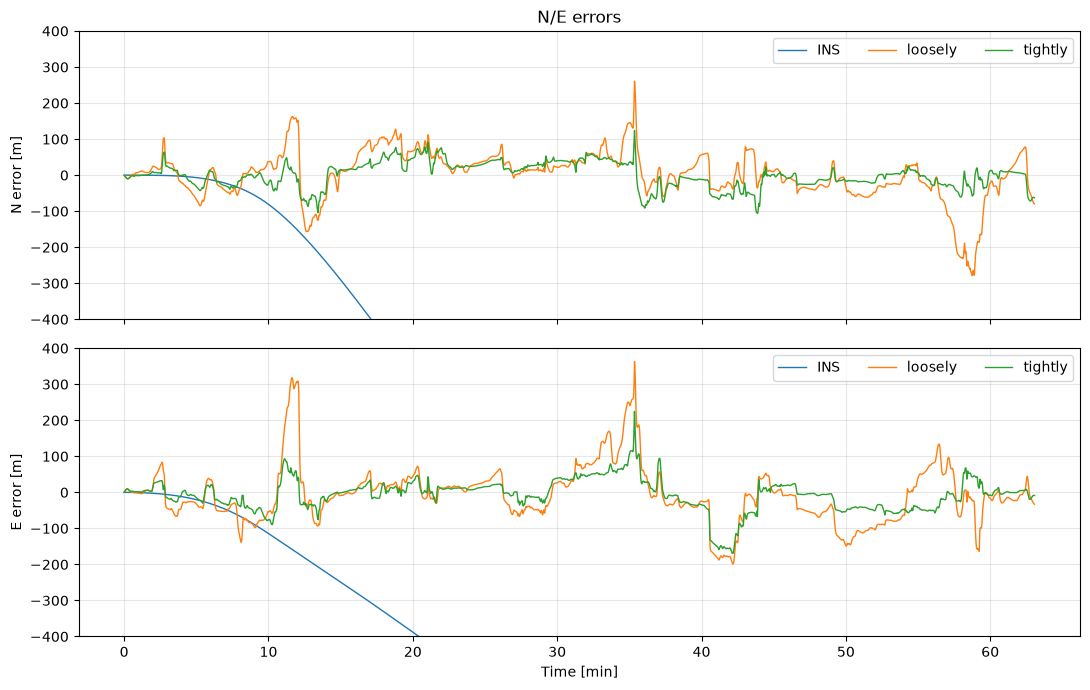

In [8]:
viz.plot_ne_errors(tt, lat, lon,
    {'INS': (ins_res,'tab:blue'), 'loosely': (loose,'tab:orange'), 'tightly': (tight,'tab:green')});

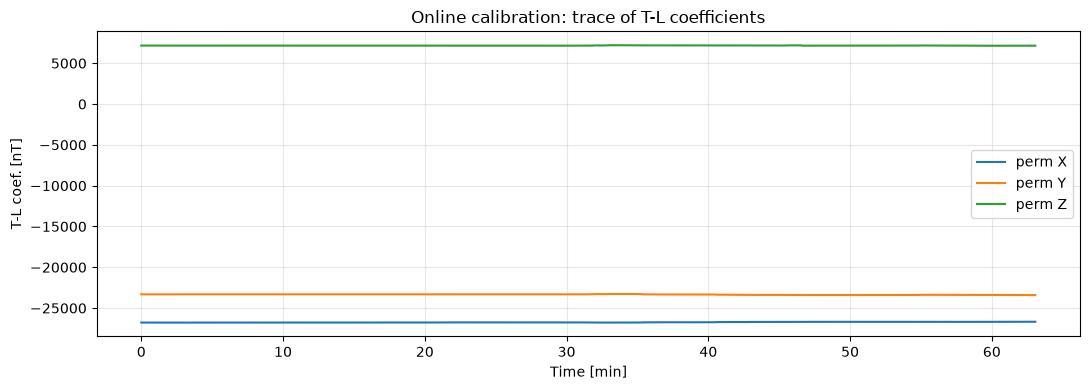

In [9]:
viz.plot_tl_online(tt, tight.extras['tl']);

On SGL data this gives loosely ~104 m, tightly ~57 m (~45% improvement), qualitatively matching Table I of the paper (F-16: 111 m → 59 m). To run on other flights, change the flight/window (see `data.NAV_WINDOWS`).